In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

In [42]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
from analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
from analytics.ps2_dataset import SortPreprocessor
from spec.enums import EventType

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []
submit_event = EventType.Submit
grades_link_table = "Subject"
grades_col = None
start_time = None
end_time = None
early_percentage = None
assignment_ids = None
compile_error_type_col = Cols.CompileMessageType
compile_event = EventType.Compile
compile_error_event = EventType.CompileError
output_suffix = ''

# Note: Only Fall has compilation data; spring has no Run.Program events!
edwards_s19_config = {
    "config_path": "sample_data_configs/edwards2019.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
        # Make sure this comes last so Fall is correct
        ClassSubsetPreprocessor("Spring"),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2019-02-25 00:00:00",
    "early_percentage": 0.23,
    "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
    "grades_col": "exam2",
    "output_suffix": "-s19",
}

edwards_f19_config = edwards_s19_config.copy()
edwards_f19_config["proprocessing_steps"] = edwards_s19_config["proprocessing_steps"].copy()
edwards_f19_config["proprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
edwards_f19_config["end_time"] = "2019-10-13 00:00:00"
edwards_f19_config["assignment_ids"] = ["p4f", "p5f"]
edwards_f19_config["early_percentage"] = 0.42
edwards_f19_config["output_suffix"] = "-f19"

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2022-01-01 00:00:00",
    "early_percentage": 0.4,
    "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
    "grades_col": "FinalScore",
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.33,
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.25,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
    "main_table_preprocessing_steps": [
        CodeBenchAddParentEventIDs(),
    ],
    "grades_link_table": "CourseSubject",
    "grades_col": "final-grade",
    "start_time": "2024-09-01 00:00:00",
    "early_percentage": 0.28,
    "compile_error_type_col": "ProgramErrorOutput",
    "compile_event": EventType.Submit,
    "compile_error_event": EventType.RunTest,
}

# config = cwo_f19_config
# config = cwo_s19_config
config = codebench2024_config
# config = edwards2021_config
# config = edwards_s19_config
# config = edwards_f19_config
locals().update(config)

In [43]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [44]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(proprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [ ]:
main_table = dataset.get_main_table()
main_table.head()

In [6]:
main_table[problem_id_col].unique()

array([9.52973360e+07, 1.47186460e+09,            nan, 2.11162095e+08,
       2.65057258e+09, 3.22114887e+09, 2.14935957e+09, 1.46768578e+09,
       4.19050234e+09, 3.59632665e+08, 1.46336312e+08, 3.44441700e+09,
       1.96428582e+09, 3.94019784e+09, 8.54576230e+08, 3.53028508e+09,
       3.78836843e+09, 2.91286518e+08, 3.54104495e+08, 3.90279466e+09,
       7.04983377e+08, 2.66703647e+09, 1.92744696e+09, 3.80600233e+09,
       2.38323920e+09, 2.13296653e+09, 4.23386584e+09, 3.45594222e+09,
       2.81977940e+09, 1.62681778e+09, 1.46291550e+09, 4.86841780e+07,
       3.69128446e+09, 1.07807600e+09, 1.71966988e+09, 3.92183032e+09,
       7.75838323e+08, 1.07644840e+09, 4.01168773e+09, 1.93441519e+09,
       3.90236538e+09, 2.86258240e+09, 1.39669844e+09, 2.52083898e+09,
       7.95845062e+08, 3.04419971e+09, 6.74628499e+08, 1.09221412e+09,
       3.59761547e+08, 2.28895812e+09, 1.41762062e+09, 1.21032330e+09,
       1.42023258e+09, 2.33251343e+09, 2.77638590e+09, 1.10664557e+09,
      

In [7]:
bad_assignment_ids = [407610653, 1147927607, 1407437764]
main_table = main_table[~main_table[Cols.AssignmentID].isin(bad_assignment_ids)]

In [8]:
if start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= start_time]
if end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= end_time]

In [9]:
if "X-ClassID" in main_table.columns:
    class_counts = main_table["X-ClassID"].value_counts()
    print(class_counts)
    min_count = 1000
    invalid_class_ids = class_counts[class_counts < min_count].index
    print(f"Removing classes with less than {min_count} submissions: {invalid_class_ids}")
    main_table = main_table[~main_table["X-ClassID"].isin(invalid_class_ids) & ~main_table["X-ClassID"].isna()]

X-ClassID
2.298943e+09    1204023
3.648409e+09    1101398
3.758479e+09    1037972
9.455914e+08     844736
2.607741e+09     422938
1.349132e+09     243459
9.197531e+08        387
4.049260e+09        311
2.248340e+09          2
Name: count, dtype: int64
Removing classes with less than 1000 submissions: Index([919753123.0, 4049259557.0, 2248339634.0], dtype='float64', name='X-ClassID')


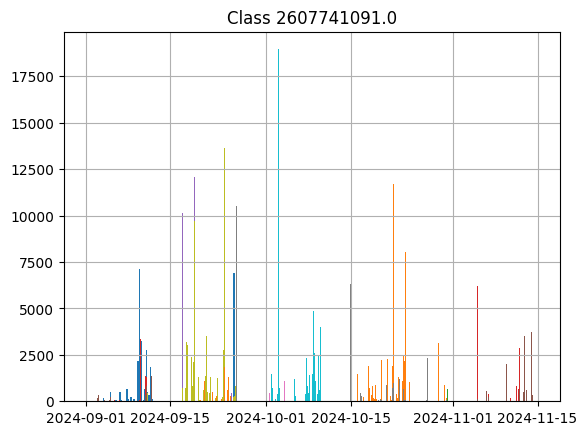

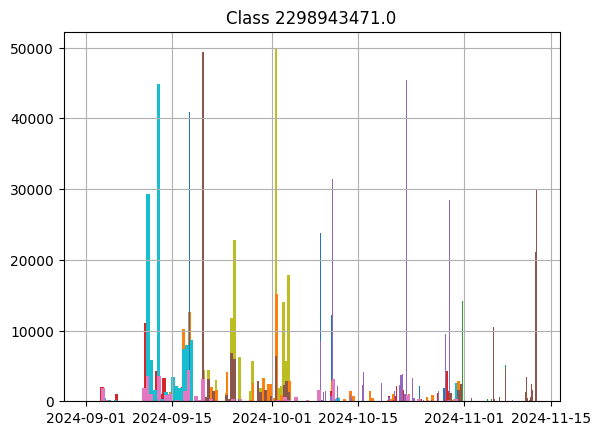

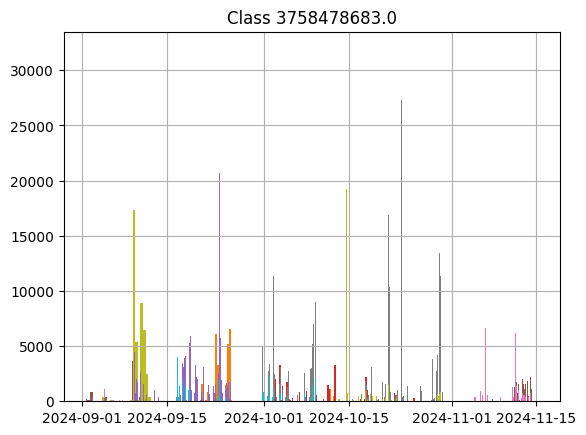

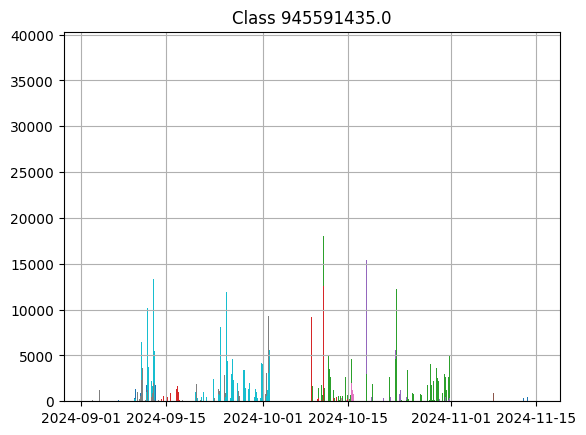

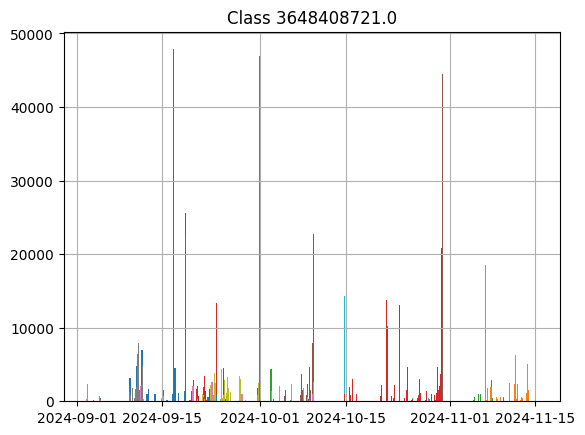

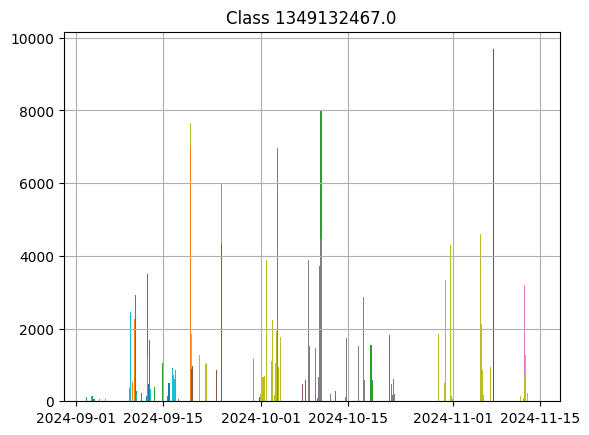

In [10]:
if "X-ClassID" not in main_table.columns:
    main_table.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
else:
    classes = main_table["X-ClassID"].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table["X-ClassID"] == class_id]
        hist = subset.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        plt.show()

In [11]:
import numpy as np
for i in main_table[timestamp_col].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2024-09-01 01:35:32.500000
2024-09-09 14:55:15.499750144
2024-09-09 22:40:18.527000064
2024-09-10 15:48:46.463749888
2024-09-10 19:23:54.851000064
2024-09-10 22:58:02.735500032
2024-09-11 02:59:40.511500032
2024-09-11 14:23:44.017499904
2024-09-11 17:14:52.190000128
2024-09-11 18:40:13.632750080
2024-09-12 00:09:40.865500160
2024-09-12 18:10:06.244250112
2024-09-12 19:32:21.510000128
2024-09-13 02:33:10.078499840
2024-09-16 00:49:04.368999936
2024-09-16 17:04:16.838000128
2024-09-16 19:21:29.988000
2024-09-17 01:07:06.188000
2024-09-17 15:15:54.643500032
2024-09-17 18:14:53.639500032
2024-09-17 19:12:55.940999936
2024-09-17 23:03:06.654249984
2024-09-18 15:19:50.046499840
2024-09-18 19:05:38.106249984
2024-09-19 00:38:00.364000
2024-09-19 18:29:07.789749760
2024-09-19 20:38:19.884499968
2024-09-20 20:41:35.181750016
2024-09-21 23:59:54.903000064
2024-09-23 13:10:43.831500032
2024-09-23 17:14:37.292499968
2024-09-23 19:07:54.889999872
2024-09-24 00:52:04.836000
2024-09-24 18:20:04.82624

In [30]:
#get the data of the third quantile
max = main_table[timestamp_col].max()
min = main_table[timestamp_col].min()
range = max - min
time_cutoff = min + range * early_percentage
print(time_cutoff)
print(main_table[timestamp_col].min())
print(main_table[timestamp_col].max())

data_subset = main_table[main_table[timestamp_col] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
if Cols.ProblemID in data_subset.columns:
    print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
print("Percent of logs: ", len(data_subset) / len(main_table) * 100)
print(f"Percent of assignments: {len(data_subset[Cols.AssignmentID].unique())} / {len(main_table[Cols.AssignmentID].unique())}")
if Cols.ProblemID in main_table.columns:
    print(f"Percent of problems: {len(data_subset[Cols.ProblemID].unique())} / {len(main_table[Cols.ProblemID].unique())}")
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2024-09-22 03:30:01.756800
2024-09-01 01:35:32.500000
2024-11-15 08:24:25.560000
Assignment IDs: [2.61168503e+09            nan 2.01335709e+09 4.27067005e+09
 1.36085055e+09 1.36006365e+09 3.09679449e+09 3.46621932e+09
 1.98032895e+09 2.90983374e+08 5.85776055e+08 1.99881010e+07
 5.58149337e+08 7.59078646e+08 2.14537607e+09 1.19249144e+08
 2.40815043e+08 2.74582803e+09 3.68109256e+08 2.78087063e+09
 3.91324454e+09 2.14815632e+09 1.70419381e+09 1.03734466e+09
 2.49103774e+08 3.97028108e+09 1.89665852e+09 4.59282688e+08
 1.42445494e+09 5.37498399e+08 4.19534388e+09 2.64970633e+09
 6.31605243e+08 1.79874337e+09 1.53863738e+09 2.77068275e+09
 1.67328901e+09 2.63606915e+08 1.46735927e+09 2.39917035e+09
 2.46122119e+09 1.94310873e+09 2.45531908e+09 2.56441098e+09
 3.78444757e+09 3.21038643e+09 4.07059535e+09 1.98739987e+09]
Problem IDs: [3.90279466e+09            nan 2.11162095e+08 3.78836843e+09
 3.94019784e+09 2.13296653e+09 4.23386584e+09 7.04983377e+08
 2.65057258e+09 3.44441700e+09 3.22

ProblemID
2.993559e+08    1.000000
3.166143e+08    1.000000
8.740456e+08    1.000000
9.710107e+08    1.000000
6.807115e+08    1.000000
6.056547e+08    1.000000
6.046741e+08    1.000000
4.949824e+08    1.000000
1.128388e+09    1.000000
1.210323e+09    1.000000
1.245235e+09    1.000000
1.420233e+09    1.000000
1.092214e+09    1.000000
1.106646e+09    1.000000
1.057322e+09    1.000000
1.417621e+09    1.000000
1.050674e+09    1.000000
2.332513e+09    1.000000
2.510512e+09    1.000000
2.086142e+09    1.000000
1.914302e+09    1.000000
4.228376e+09    1.000000
3.968058e+09    1.000000
3.900747e+09    1.000000
3.348296e+09    1.000000
3.449544e+09    1.000000
3.306862e+09    1.000000
3.833385e+09    1.000000
3.836350e+09    1.000000
4.204267e+09    1.000000
2.776386e+09    1.000000
2.559670e+09    1.000000
2.249046e+09    1.000000
2.011583e+09    1.000000
1.720053e+09    1.000000
1.435819e+09    1.000000
3.455942e+09    0.991956
2.132967e+09    0.987977
1.078076e+09    0.984339
1.076448e+09   

C:\Users\twprice\AppData\Local\Temp\ipykernel_26516\1718260821.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  problem_percentages = main_table[main_table[problem_id_col].isin(included_problem_ids)].groupby(problem_id_col).apply(lambda x: (x[timestamp_col] < time_cutoff).mean())


<Axes: >

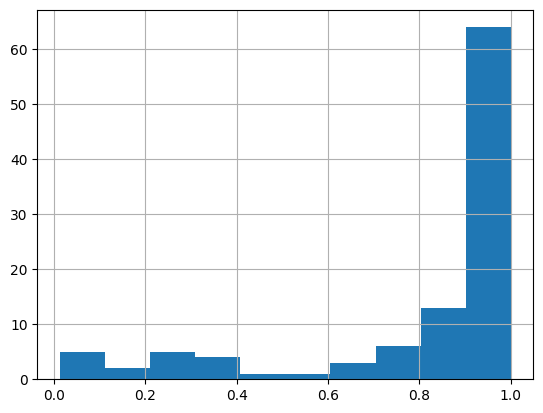

In [31]:
included_problem_ids = data_subset[problem_id_col].unique()
problem_percentages = main_table[main_table[problem_id_col].isin(included_problem_ids)].groupby(problem_id_col).apply(lambda x: (x[timestamp_col] < time_cutoff).mean())
problem_percentages.sort_values(ascending=False, inplace=True)
# Print the whole dataframe, ignoring row limits
with pd.option_context('display.max_rows', None):
    print(problem_percentages)

problem_percentages.hist()


In [32]:
if assignment_ids is not None:
    data_subset = data_subset[data_subset[Cols.AssignmentID].isin(assignment_ids)]

In [37]:
precluded_problems = problem_percentages[problem_percentages < 0.5].index
len_before = len(data_subset)
data_subset = data_subset[~data_subset[problem_id_col].isin(precluded_problems)]
print(f"Precluded problems: {precluded_problems}")
print(f"Removed {100 - 100 * len(data_subset) / len_before:.2f}% of data")

print(f"Percent of assignments: {len(data_subset[Cols.AssignmentID].unique())} / {len(main_table[Cols.AssignmentID].unique())}")
if Cols.ProblemID in main_table.columns:
    print(f"Percent of problems: {len(data_subset[Cols.ProblemID].unique())} / {len(main_table[Cols.ProblemID].unique())}")

Precluded problems: Index([ 359761547.0, 4093783519.0,   95297336.0, 1492666623.0, 2288958116.0,
       1471864603.0,  977898820.0,  760184605.0, 4142573950.0, 4047911046.0,
       2183397041.0, 1115642599.0, 3925461154.0, 3217182174.0, 3561285162.0,
       2185634355.0, 1147063670.0],
      dtype='float64', name='ProblemID')
Removed 0.00% of data
Percent of assignments: 41 / 114
Percent of problems: 88 / 280


In [34]:
testing_student_subset = data_subset[Cols.SubjectID].unique()[:50]
testing_mt_subset = data_subset[data_subset[Cols.SubjectID].isin(testing_student_subset)]

In [15]:
grouping_cols = ["X-ClassID", Cols.SubjectID, problem_id_col]
grouping_cols = [col for col in grouping_cols if col in main_table.columns]

In [38]:
main_table[compile_error_type_col].value_counts()

ProgramErrorOutput
Resources/ErrorOutput/19988101_2741392081.txt      1031
Resources/ErrorOutput/3676363011_2028983084.txt     793
Resources/ErrorOutput/2745828033_2482206358.txt     790
Resources/ErrorOutput/4070595350_995293357.txt      675
Resources/ErrorOutput/3676363011_3835755903.txt     651
Resources/ErrorOutput/1719349602_1637866682.txt     638
Resources/ErrorOutput/3020318285_873175644.txt      620
Resources/ErrorOutput/2461221192_1637866682.txt     591
Resources/ErrorOutput/2461221192_1036297951.txt     582
Resources/ErrorOutput/2461221192_2482206358.txt     552
Resources/ErrorOutput/2626837793_1822403484.txt     518
Resources/ErrorOutput/1574433768_2741392081.txt     482
Resources/ErrorOutput/2626837793_995293357.txt      475
Resources/ErrorOutput/3784447574_1637866682.txt     474
Resources/ErrorOutput/3245772656_1822403484.txt     474
Resources/ErrorOutput/1037344655_2741392081.txt     450
Resources/ErrorOutput/759078646_2482206358.txt      450
Resources/ErrorOutput/2552104

In [39]:
from analytics.metrics.errors import ErrorMetrics


error_metrics = ErrorMetrics(True,
                             compile_message_type_column=compile_error_type_col,
                             compile_event=compile_event,
                             compile_error_event=compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

KeyError: <MainTableColumns.ParentEventID: 'ParentEventID'>

In [ ]:
# Investigating a single Edwards 2021 student to see why EQ/RED are so low
# Errors tend not to be repeated and there are many successful runs
# data_subset[
#     (data_subset[Cols.SubjectID] == "Student1") &
#     (data_subset[Cols.AssignmentID] == "Assign7") &
#     ((data_subset[Cols.EventType] == EventType.CompileError) | (data_subset[Cols.EventType] == EventType.RunProgram))
# ].head(40)

In [ ]:
# EQ is very low for codebench because most runs have no errors
# It's interesting/odd that EQ and RED don't correlate on this dataset

error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,285.000000,285.000000,345.000000
mean,0.156177,2.168186,4.266667
std,0.199243,5.092311,7.767229
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.074074,0.500000,2.000000
75%,0.257053,1.833333,5.000000
max,1.000000,46.397076,63.000000


In [ ]:
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,1.000000,0.917470,0.869776
RepeatedErrorDensity,0.917470,1.000000,0.919664
FailedCompileCount,0.869776,0.919664,1.000000


<Axes: ylabel='Frequency'>

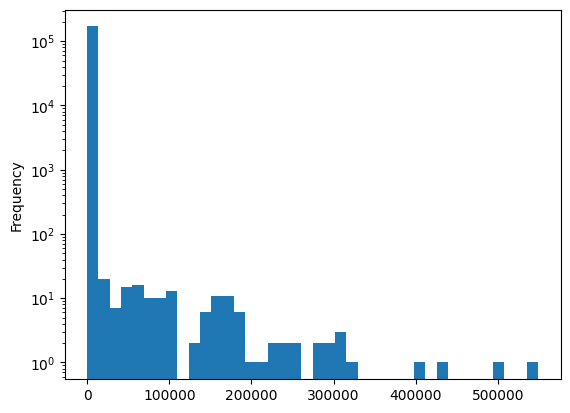

In [ ]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(testing_mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [ ]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00       0.000017
0.25       0.002133
0.50       0.003250
0.75       0.008983
0.80       0.012067
0.85       0.017200
0.90       0.029783
0.95       0.073903
0.96       0.101217
0.97       0.152681
0.98       0.269888
0.99       0.623537
1.00    9148.502867
Name: DeltaSeconds, dtype: float64

In [ ]:
from analytics.metrics.time import TimeMetrics

time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_3732\3223447471.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
X-ClassID SubjectID AssignmentID                                       
Fall      S000      p4f              959.112      472.528   1431.640   
          S002      p4f              650.710      358.738   1009.448   
                    p5f             2048.079     1945.370   3993.449   
          S003      p4f             3334.401     1639.570   4973.971   
                    p5f             1332.563     1503.432   2835.995   
...                                      ...          ...        ...   
          S512      p5f             1324.711      915.508   2240.219   
          S513      p5f             1155.008      581.442   1736.450   
          S514      p5f             1502.551      804.726   2307.277   
          S515      p5f             2438.112     2304.530   4742.642   
          S516      p5f               36.585      144.438    181.023   

                                  ActiveTimeAfterCorrect  #Breaks  \
X-ClassID SubjectID AssignmentID                                    
Fall      S000      p4f                             0.00        1   
          S002      p4f                             0.00        0   
                    p5f                             0.00        2   
          S003      p4f                             0.00        2   
                    p5f                             0.00        3   
...                                                  ...      ...   
          S512      p5f                             0.00        0   
          S513      p5f                             0.01        0   
          S514      p5f                             0.00        2   
          S515      p5f                             0.00        5   
          S516      p5f                             0.00        0   

                                                        StartTime  \
X-ClassID SubjectID AssignmentID                                    
Fall      S000      p4f          2019-09-11 22:58:24.669000+00:00   
          S002      p4f          2019-09-13 07:04:51.585000+00:00   
                    p5f          2019-09-20 04:23:18.525000+00:00   
          S003      p4f          2019-09-12 22:38:13.377000+00:00   
                    p5f          2019-09-21 03:19:22.467000+00:00   
...                                                           ...   
          S512      p5f          2019-09-18 02:15:44.601000+00:00   
          S513      p5f          2019-09-19 16:38:30.812000+00:00   
          S514      p5f          2019-09-16 18:27:40.395000+00:00   
          S515      p5f          2019-09-17 00:11:33.343000+00:00   
          S516      p5f          2019-09-19 17:17:33.777000+00:00   

                                                 FirstCorrectTime  \
X-ClassID SubjectID AssignmentID                                    
Fall      S000      p4f                                       NaT   
          S002      p4f          2019-09-13 07:21:41.033000+00:00   
                    p5f          2019-09-20 05:37:13.384000+00:00   
          S003      p4f                                       NaT   
                    p5f                                       NaT   
...                                                           ...   
          S512      p5f          2019-09-18 02:53:04.820000+00:00   
          S513      p5f          2019-09-19 17:07:27.262000+00:00   
          S514      p5f          2019-09-16 19:14:01.964000+00:00   
          S515      p5f                                       NaT   
          S516      p5f                                       NaT   

                                                          EndTime  
X-ClassID SubjectID AssignmentID                                   
Fall      S000      p4f          2019-09-11 23:26:14.402000+00:00  
          S002      p4f          2019-09-13 07:22:00.393000+00:00  
                    p5f          2019-09-20 05:37:13.384000+00:00  
          S003      p4f          2019-09-13 00:10:57.005000+00:

In [ ]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks
count,345.000000,345.000000,345.000000,345.000000,345.000000
mean,1461.116606,1099.469348,2560.585954,12.267267,3.628986
std,1138.603816,1053.233282,2102.497134,99.505069,4.777159
min,2.570000,0.000000,2.570000,0.000000,0.000000
25%,682.441000,346.148000,1041.935000,0.000000,1.000000
50%,1198.589000,788.861000,2015.449000,0.000000,2.000000
75%,2010.674000,1551.636000,3594.681000,0.029000,5.000000
max,5895.247000,6597.244000,12314.430000,1774.781000,44.000000


In [ ]:
result.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.884608,0.973826,0.032063,0.644588,0.196405,0.332346,0.305888
PassiveTime,0.884608,1.000000,0.963478,-0.002582,0.723041,0.288293,0.445028,0.407868
TotalTime,0.973826,0.963478,1.000000,0.014433,0.701370,0.241319,0.391539,0.359657
ActiveTimeAfterCorrect,0.032063,-0.002582,0.014433,1.000000,-0.092237,-0.216764,-0.227536,-0.138592
#Breaks,0.644588,0.723041,0.701370,-0.092237,1.000000,0.150872,0.362045,0.337892
StartTime,0.196405,0.288293,0.241319,-0.216764,0.150872,1.000000,0.940964,0.902975
FirstCorrectTime,0.332346,0.445028,0.391539,-0.227536,0.362045,0.940964,1.000000,0.958654
EndTime,0.305888,0.407868,0.359657,-0.138592,0.337892,0.902975,0.958654,1.000000


In [ ]:
result["FirstCorrectTime"].isna().mean()

np.float64(0.08985507246376812)

In [ ]:
result["StartTime"].isna().mean()

np.float64(0.0)

In [ ]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_3732\1178317524.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [ ]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  \
X-ClassID SubjectID AssignmentID                                        
Fall      S000      p4f                  0         False        False   
          S002      p4f                  1          True         True   
                    p5f                  4         False         True   
          S003      p4f                  6         False        False   
                    p5f                  1         False        False   

                                  Attempted  MaxScore  MinScore  MeanScore  \
X-ClassID SubjectID AssignmentID                                             
Fall      S000      p4f               False       0.0       0.0        0.0   
          S002      p4f                True      90.0      90.0       90.0   
                    p5f                True      90.0      90.0       90.0   
          S003      p4f                True       NaN       NaN        NaN   
                    p5f                True       NaN       NaN        NaN   

                                  TotalAttempts  
X-ClassID SubjectID AssignmentID                 
Fall      S000      p4f                       0  
          S002      p4f                       1  
                    p5f                       4  
          S003      p4f                       6  
                    p5f                       1

In [ ]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,345.000000,322.000000,322.000000,322.000000,345.000000
mean,1.921739,92.962733,92.962733,92.962733,1.921739
std,1.611087,18.236509,18.236509,18.236509,1.611087
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,95.000000,95.000000,95.000000,1.000000
50%,1.000000,100.000000,100.000000,100.000000,1.000000
75%,2.000000,100.000000,100.000000,100.000000,2.000000
max,14.000000,100.000000,100.000000,100.000000,14.000000


In [ ]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features = pd.merge(
    all_features,
    error_results.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,X-ClassID,SubjectID,AssignmentID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,Fall,S000,p4f,959.112,472.528,1431.640,0.0,1,2019-09-11 22:58:24.669000+00:00,NaT,...,False,False,False,0.0,0.0,0.0,0,NaN,NaN,0.0
1,Fall,S002,p4f,650.710,358.738,1009.448,0.0,0,2019-09-13 07:04:51.585000+00:00,2019-09-13 07:21:41.033000+00:00,...,True,True,True,90.0,90.0,90.0,1,0.176471,2.250000,6.0
2,Fall,S002,p5f,2048.079,1945.370,3993.449,0.0,2,2019-09-20 04:23:18.525000+00:00,2019-09-20 05:37:13.384000+00:00,...,False,True,True,90.0,90.0,90.0,4,0.191919,1.333333,8.0
3,Fall,S003,p4f,3334.401,1639.570,4973.971,0.0,2,2019-09-12 22:38:13.377000+00:00,NaT,...,False,False,True,NaN,NaN,NaN,6,0.621212,1.833333,5.0
4,Fall,S003,p5f,1332.563,1503.432,2835.995,0.0,3,2019-09-21 03:19:22.467000+00:00,NaT,...,False,False,True,NaN,NaN,NaN,1,NaN,NaN,0.0


In [ ]:
all_features.isna().mean()

X-ClassID                 0.000000
SubjectID                 0.000000
AssignmentID              0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.089855
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.066667
MinScore                  0.066667
MeanScore                 0.066667
TotalAttempts             0.000000
ErrorQuotient             0.173913
RepeatedErrorDensity      0.173913
FailedCompileCount        0.000000
dtype: float64

In [ ]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

KeyError: <MainTableColumns.ProblemID: 'ProblemID'>

In [ ]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [ ]:
all_features_z.head()

,X-ClassID,SubjectID,AssignmentID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,Fall,S000,p4f,-0.220210,-0.325584,-0.279119,-0.127199,-0.477690,-0.116946,-3.349642,...,-6.582288,-6.582288,-6.582288,-1.345185,NaN,NaN,-0.698342,0.997089,-1.602596,0.411192
1,Fall,S002,p4f,-0.563786,-0.505977,-0.571500,-0.127199,-0.863431,0.633385,0.296821,...,-0.423347,-0.423347,-0.423347,-0.672593,-0.061955,-0.084809,-0.046725,-0.997089,-1.602596,-2.417812
2,Fall,S002,p5f,0.224328,0.352162,0.297421,-0.197252,-0.508288,0.705624,0.329171,...,0.012540,0.012540,0.012540,1.248702,0.440272,-0.002169,1.131759,0.991359,-1.002886,0.591211
3,Fall,S003,p4f,2.425987,1.524541,2.174058,-0.127199,-0.091950,0.436055,-3.349642,...,NaN,NaN,NaN,2.690371,2.163466,-0.157602,-0.155327,0.997089,-1.602596,0.411192
4,Fall,S003,p5f,-0.340089,-0.012515,-0.186653,-0.197252,-0.339509,1.143319,-3.020501,...,NaN,NaN,NaN,-0.488768,NaN,NaN,-0.406900,-1.002886,-1.002886,-1.681667


In [ ]:
all_features_z.RepeatedErrorDensity.isna().mean()

np.float64(0.17391304347826086)

In [ ]:
all_na_eq = all_features.groupby(Cols.SubjectID).ErrorQuotient.apply(lambda x: pd.isna(x).all())
all_na_eq = all_na_eq[all_na_eq]
all_na_eq

SubjectID
S000    True
S029    True
S034    True
S118    True
S119    True
S134    True
S146    True
S155    True
S156    True
S161    True
S163    True
S177    True
S198    True
S229    True
S236    True
S272    True
S279    True
S291    True
S312    True
S355    True
S370    True
S490    True
S513    True
Name: ErrorQuotient, dtype: bool

In [ ]:
# In CWO, this student attempted all of 1 problem, got and error and gave up
# I think assigning a 1 makes more sense than a 0... but 0 is more generic and
# it's rare enough I'm not going to worry about it right now
data_subset[data_subset[Cols.SubjectID].isin(all_na_eq.index)]

,EventID,SubjectID,AssignmentID,CodeStateSection,X-Task,EventType,X-Keystroke,InsertText,DeleteText,SourceLocation,...,X-RunOutput,X-RunHasError,X-RunUserTerminated,X-RawAssignmentID,X-Term,X-Compilable,CompileMessageType,ParentEventID,Score,X-ClassID
0,0,S000,p4f,task0.py,0,File.Edit,#,#,NaN,0.0,...,NaN,NaN,NaN,p4,f,1,NaN,NaN,NaN,Fall
1,1,S000,p4f,task0.py,0,File.Edit,space,,NaN,1.0,...,NaN,NaN,NaN,p4,f,1,NaN,NaN,NaN,Fall
2,2,S000,p4f,task0.py,0,File.Edit,delete,NaN,,1.0,...,NaN,NaN,NaN,p4,f,1,NaN,NaN,NaN,Fall
3,3,S000,p4f,task0.py,0,File.Edit,space,,NaN,1.0,...,NaN,NaN,NaN,p4,f,1,NaN,NaN,NaN,Fall
4,4,S000,p4f,task0.py,0,File.Edit,@,@,NaN,2.0,...,NaN,NaN,NaN,p4,f,1,NaN,NaN,NaN,Fall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745891,2994431,S177,p5f,task0.py,0,Submit,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,p5,f,1,NaN,NaN,NaN,Fall
1745892,2994432,S177,p5f,task0.py,0,Submit,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,p5,f,1,NaN,NaN,75.0,Fall
1638141,2739674,S163,p5f,task1.py,1,File.Edit,NaN,# Task 2,NaN,0.0,...,NaN,NaN,NaN,p5,f,1,NaN,NaN,NaN,Fall
1638142,2739675,S163,p5f,task1.py,1,File.Edit,return,\n,NaN,8.0,...,NaN,NaN,NaN,p5,f,1,NaN,NaN,NaN,Fall


In [ ]:
merge_cols = grouping_cols.copy()
merge_cols.remove(problem_id_col)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).mean()
# In theory this can happen is someone only has NA for all problems
# This apparently happened with EQ in CWO...

# For EQ, having no attempts with compile errors should give you
# the max value (whatever 1 is after normalization)
for col in [ErrorMetrics.ERROR_QUOTIENT]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for RED it should be the minimum value (normalized 0)
for col in [ErrorMetrics.REPEATED_ERROR_DENSITY, SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID SubjectID                                       
Fall      S000        -0.220210    -0.325584  -0.279119   
          S002        -0.169729    -0.076907  -0.137039   
          S003         1.042949     0.756013   0.993702   
          S004         1.581642     0.138399   1.015704   
          S005         0.420785     0.295195   0.397134   

                     ActiveTimeAfterCorrect   #Breaks  StartTime  \
X-ClassID SubjectID                                                
Fall      S000                    -0.127199 -0.477690  -0.116946   
          S002                    -0.162225 -0.685859   0.669505   
          S003                    -0.162225 -0.215730   0.789687   
          S004                    -0.130715 -0.239821  -0.593473   
          S005                    -0.146751  0.061530  -1.075323   

                     FirstCorrectTime   EndTime  Attempts  FirstCorrect  ...  \
X-ClassID SubjectID                                                      ...   
Fall      S000              -3.349642 -0.745879 -1.345185           0.0  ...   
          S002               0.312996  0.111345  0.288055           0.5  ...   
          S003              -3.185071  0.380842  1.100801           0.0  ...   
          S004               0.312948 -0.312920  0.381491           0.0  ...   
          S005               0.312907 -2.035643  0.091912           0.5  ...   

                     MaxScore  MinScore  MeanScore  TotalAttempts  \
X-ClassID SubjectID                                                 
Fall      S000      -6.582288 -6.582288  -6.582288      -1.345185   
          S002      -0.205404 -0.205404  -0.205404       0.288055   
          S003      -6.582288 -6.582288  -6.582288       1.100801   
          S004       0.377108  0.377108   0.377108       0.381491   
          S005       0.206027  0.206027   0.206027       0.091912   

                     ErrorQuotient  RepeatedErrorDensity  FailedCompileCount  \
X-ClassID SubjectID                                                            
Fall      S000            3.052143             -0.477888           -0.698342   
          S002            0.189159             -0.043489            0.542517   
          S003            2.163466             -0.157602           -0.281114   
          S004            0.670414              0.209075           -0.063908   
          S005           -0.241618             -0.004449           -0.118209   

                     AtLeatMedianActiveTime  AtLeatMedianMaxScore  HadEffort  
X-ClassID SubjectID                                                           
Fall      S000                     0.997089             -1.602596   0.411192  
          S002                    -0.002865             -1.302741  -0.913300  
          S003                    -0.002899             -1.302741  -0.635237  
          S004                     0.994224              0.805859   0.501202  
          S005                     0.994224             -0.305619   0.501202  

[5 rows x 22 columns]

In [ ]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).sum()
subject_totals.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID SubjectID                                       
Fall      S000        -0.220210    -0.325584  -0.279119   
          S002        -0.339458    -0.153815  -0.274079   
          S003         2.085898     1.512026   1.987405   
          S004         3.163283     0.276797   2.031409   
          S005         0.841570     0.590391   0.794268   

                     ActiveTimeAfterCorrect   #Breaks  StartTime  \
X-ClassID SubjectID                                                
Fall      S000                    -0.127199 -0.477690  -0.116946   
          S002                    -0.324451 -1.371719   1.339009   
          S003                    -0.324451 -0.431459   1.579374   
          S004                    -0.261429 -0.479641  -1.186947   
          S005                    -0.293502  0.123060  -2.150645   

                     FirstCorrectTime   EndTime  Attempts  FirstCorrect  ...  \
X-ClassID SubjectID                                                      ...   
Fall      S000              -3.349642 -0.745879 -1.345185             0  ...   
          S002               0.625992  0.222691  0.576109             1  ...   
          S003              -6.370143  0.761684  2.201603             0  ...   
          S004               0.625895 -0.625840  0.762981             0  ...   
          S005               0.625814 -4.071286  0.183825             1  ...   

                     MaxScore  MinScore  MeanScore  TotalAttempts  \
X-ClassID SubjectID                                                 
Fall      S000      -6.582288 -6.582288  -6.582288      -1.345185   
          S002      -0.410808 -0.410808  -0.410808       0.576109   
          S003       0.000000  0.000000   0.000000       2.201603   
          S004       0.754217  0.754217   0.754217       0.762981   
          S005       0.412053  0.412053   0.412053       0.183825   

                     ErrorQuotient  RepeatedErrorDensity  FailedCompileCount  \
X-ClassID SubjectID                                                            
Fall      S000            0.000000              0.000000           -0.698342   
          S002            0.378317             -0.086978            1.085035   
          S003            2.163466             -0.157602           -0.562227   
          S004            1.340828              0.418149           -0.127815   
          S005           -0.483237             -0.008899           -0.236418   

                     AtLeatMedianActiveTime  AtLeatMedianMaxScore  HadEffort  
X-ClassID SubjectID                                                           
Fall      S000                     0.997089             -1.602596   0.411192  
          S002                    -0.005730             -2.605482  -1.826601  
          S003                    -0.005797             -2.605482  -1.270474  
          S004                     1.988447              1.611718   1.002403  
          S005                     1.988447             -0.611237   1.002403  

[5 rows x 22 columns]

In [ ]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Fall,S000,-0.220210,-0.325584,-0.279119,-0.127199,-0.477690,-0.116946,-3.349642,-0.745879,...,-6.582288,-6.582288,-6.582288,-1.345185,0.000000,0.000000,-0.698342,0.997089,-1.602596,0.411192
1,Fall,S002,-0.169729,-0.076907,-0.137039,-0.162225,-0.685859,0.669505,0.312996,0.111345,...,-0.410808,-0.410808,-0.410808,0.576109,0.378317,-0.086978,1.085035,-0.005730,-2.605482,-1.826601
2,Fall,S003,1.042949,0.756013,0.993702,-0.162225,-0.215730,0.789687,-3.185071,0.380842,...,0.000000,0.000000,0.000000,2.201603,2.163466,-0.157602,-0.562227,-0.005797,-2.605482,-1.270474
3,Fall,S004,1.581642,0.138399,1.015704,-0.130715,-0.239821,-0.593473,0.312948,-0.312920,...,0.754217,0.754217,0.754217,0.762981,1.340828,0.418149,-0.127815,1.988447,1.611718,1.002403
4,Fall,S005,0.420785,0.295195,0.397134,-0.146751,0.061530,-1.075323,0.312907,-2.035643,...,0.412053,0.412053,0.412053,0.183825,-0.483237,-0.008899,-0.236418,1.988447,-0.611237,1.002403


In [ ]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [ ]:
assert subject_features.isna().mean().mean() == 0

In [ ]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Fall,S000,-0.208697,-0.358779,-0.285511,-0.139174,-0.523857,-0.149302,-3.121366,-0.822224,...,-5.283300e+00,-5.283300e+00,-5.283300e+00,-0.964275,0.000000,3.109529e-17,-0.521056,0.722835,-1.229980,0.314568
1,Fall,S002,-0.149385,-0.051246,-0.114604,-0.176248,-0.775043,0.707156,0.349237,0.131394,...,-3.297363e-01,-3.297363e-01,-3.297363e-01,0.412975,0.321274,-7.511276e-02,0.809580,-0.004154,-1.999688,-1.397376
2,Fall,S003,1.275436,0.978811,1.245565,-0.176248,-0.207763,0.838036,-2.965425,0.431195,...,-2.504784e-16,-2.504784e-16,-2.504784e-16,1.578185,1.837258,-1.361023e-01,-0.419496,-0.004203,-1.999688,-0.971931
3,Fall,S004,1.908366,0.215019,1.272031,-0.142895,-0.236833,-0.668248,0.349190,-0.340579,...,6.053752e-01,6.053752e-01,6.053752e-01,0.546931,1.138658,3.611072e-01,-0.095367,1.441517,1.236982,0.766853
4,Fall,S005,0.544432,0.408927,0.527953,-0.159869,0.126791,-1.192990,0.349152,-2.257020,...,3.307364e-01,3.307364e-01,3.307364e-01,0.131772,-0.410374,-7.684955e-03,-0.176399,1.441517,-0.469120,0.766853


In [ ]:
grades = dataset.get_link_table(grades_link_table)
grades.head()

,SubjectID,Group,SyntaxExercises,p4,p5,p6,p7,p8,exam1,exam2
0,S275,Spring,False,100.0,100,95.0,96.0,100.0,78.0,60.0
1,S047,Spring,False,100.0,100,95.0,100.0,100.0,82.0,80.0
2,S503,Spring,False,100.0,100,100.0,95.0,45.0,84.0,68.0
3,S032,Spring,False,50.0,90,44.0,98.0,60.0,46.0,50.0
4,S032,Fall,True,98.0,100,NaN,0.0,0.0,62.0,NaN


In [ ]:
grades.rename(columns={
    grades_col: "Grade",
    # Edwards 2019 calls it Group
    "Group": "X-ClassID",
    # CodeBench has this mislabeled
    "CourseID": "X-ClassID"},
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 0 rows with 0 grades


In [ ]:
print(f"Merging on columns: {merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[merge_cols + ["Grade"]],
    on=merge_cols,
    how="inner",
)

Merging on columns: ['X-ClassID', <MainTableColumns.SubjectID: 'SubjectID'>]


In [ ]:
print(subject_features.shape)
subject_feautres_labeled.head()

(222, 46)


,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,Fall,S002,-0.149385,-0.051246,-0.114604,-0.176248,-0.775043,0.707156,0.349237,0.131394,...,-0.329736,-0.329736,0.412975,0.321274,-0.075113,0.809580,-0.004154,-1.999688,-1.397376,80.0
1,Fall,S004,1.908366,0.215019,1.272031,-0.142895,-0.236833,-0.668248,0.349190,-0.340579,...,0.605375,0.605375,0.546931,1.138658,0.361107,-0.095367,1.441517,1.236982,0.766853,72.0
2,Fall,S005,0.544432,0.408927,0.527953,-0.159869,0.126791,-1.192990,0.349152,-2.257020,...,0.330736,0.330736,0.131772,-0.410374,-0.007685,-0.176399,1.441517,-0.469120,0.766853,86.0
3,Fall,S011,1.884103,2.750375,2.370641,-0.176248,3.181634,0.603902,0.349247,0.675481,...,-0.055098,-0.055098,-0.002184,1.189382,0.129194,0.784225,1.441517,-1.999688,0.766853,34.0
4,Fall,S012,0.411004,-0.322539,0.065544,0.910306,-0.764434,1.028838,0.364578,0.675441,...,0.202982,0.202982,0.064794,0.893240,0.414170,0.413926,0.718681,-0.769707,0.452285,68.0


In [ ]:
assert subject_feautres_labeled.groupby(merge_cols).Grade.count().max() == 1

In [ ]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, f"analysis{output_suffix}")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, f"subject_features.csv"), index=False)

184
